**Install Libraries**

In [1]:
!pip install shap xgboost --quiet

**Import Libraries**

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import shap
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


**Mount Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Define Project Paths**

In [4]:
BASE_DIR = "/content/drive/MyDrive/c01-price-forecasting"

DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "cleaned_data.csv"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "xgboost_model.pkl"
)

print("Dataset :", DATA_PATH)
print("Model   :", MODEL_PATH)

Dataset : /content/drive/MyDrive/c01-price-forecasting/data/processed/cleaned_data.csv
Model   : /content/drive/MyDrive/c01-price-forecasting/models/xgboost_model.pkl


**Load Dataset**

In [5]:
df = pd.read_csv(DATA_PATH)

# Convert date column
df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded successfully.")

Dataset loaded successfully.


**Load Trained XGBoost Model**

In [6]:
model = joblib.load(MODEL_PATH)

print("XGBoost model loaded successfully.")

XGBoost model loaded successfully.


**Dataset Overview**

In [7]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("First Five Rows")
print("="*60)

display(df.head())

Dataset Shape
(2308, 30)


First Five Rows


,date,district,paddy_type,min_price,max_price,avg_price,production_total,price_range,week_of_year,week_sin,...,year,month,week,lag_1,lag_2,lag_4,lag_12,rolling_mean_4,rolling_std_4,season_Yala
0,2015-03-26,Ampara,Long_Grain_White,34.0,40.0,37.14,307661,6.0,13,1.000000,...,2015,3,13,37.48,38.50,36.34,27.50,37.6575,0.586195,False
1,2015-04-02,Ampara,Long_Grain_White,34.0,40.0,36.40,309335,6.0,14,0.992709,...,2015,4,14,37.14,37.48,37.51,26.10,37.3800,0.872238,True
2,2015-04-09,Ampara,Long_Grain_White,34.0,39.0,35.68,309335,5.0,15,0.970942,...,2015,4,15,36.40,37.14,38.50,26.58,36.6750,0.802060,True
3,2015-04-16,Ampara,Long_Grain_White,31.0,37.0,34.97,309335,6.0,16,0.935016,...,2015,4,16,35.68,36.40,37.48,28.95,36.0475,0.933430,True
4,2015-04-23,Ampara,Long_Grain_White,30.0,38.0,34.03,309335,8.0,17,0.885456,...,2015,4,17,34.97,35.68,37.14,30.64,35.2700,1.012028,True


**Dataset Information**

In [8]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2308 entries, 0 to 2307
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2308 non-null   datetime64[ns]
 1   district          2308 non-null   object        
 2   paddy_type        2308 non-null   object        
 3   min_price         2308 non-null   float64       
 4   max_price         2308 non-null   float64       
 5   avg_price         2308 non-null   float64       
 6   production_total  2308 non-null   int64         
 7   price_range       2308 non-null   float64       
 8   week_of_year      2308 non-null   int64         
 9   week_sin          2308 non-null   float64       
 10  week_cos          2308 non-null   float64       
 11  price_t-1         2308 non-null   float64       
 12  price_t-2         2308 non-null   float64       
 13  price_t-3         2308 non-null   float64       
 14  pric

**Missing Values**

In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    display(missing)

No missing values found.


**Feature List**

In [10]:
print("="*60)
print("Columns")
print("="*60)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Columns
01. date
02. district
03. paddy_type
04. min_price
05. max_price
06. avg_price
07. production_total
08. price_range
09. week_of_year
10. week_sin
11. week_cos
12. price_t-1
13. price_t-2
14. price_t-3
15. price_t-4
16. price_t-8
17. price_t-12
18. price_4w_avg
19. price_8w_avg
20. price_change
21. year
22. month
23. week
24. lag_1
25. lag_2
26. lag_4
27. lag_12
28. rolling_mean_4
29. rolling_std_4
30. season_Yala


**Dataset Statistics**

In [11]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
date,2308,2020-10-01 00:00:00,2015-03-26 00:00:00,2017-12-28 00:00:00,2020-10-01 00:00:00,2023-07-06 00:00:00,2026-04-09 00:00:00,NaN
min_price,2308.0,67.411473,5.0,40.0,49.0,105.0,150.0,34.904248
max_price,2308.0,71.83997,22.0,42.0,52.0,112.0,160.0,35.890552
avg_price,2308.0,69.630052,21.3,41.0,50.39,107.6,152.0,35.265556
production_total,2308.0,275915.256499,26004.0,221529.0,285481.0,323867.0,530356.0,95291.480487
price_range,2308.0,4.428497,0.0,2.0,3.0,6.0,45.0,4.558968
week_of_year,2308.0,26.526863,1.0,14.0,26.0,40.0,53.0,15.054752
week_sin,2308.0,0.005554,-1.0,-0.663123,0.0,0.748511,1.0,0.707798
week_cos,2308.0,0.002817,-1.0,-0.663123,-0.0,0.748511,1.0,0.706694
price_t-1,2308.0,69.503886,21.3,40.9075,50.33,107.57,152.0,35.25424


**Target Variable Summary**

Target Variable
count    2308.000000
mean       69.630052
std        35.265556
min        21.300000
25%        41.000000
50%        50.390000
75%       107.600000
max       152.000000
Name: avg_price, dtype: float64


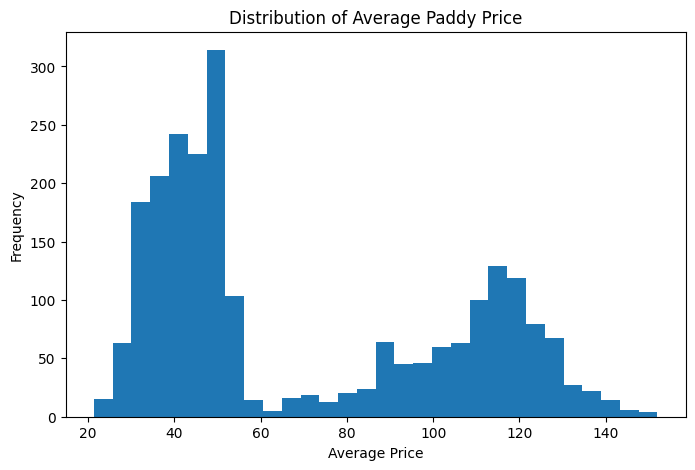

In [12]:
print("="*60)
print("Target Variable")
print("="*60)

print(df["avg_price"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["avg_price"], bins=30)

plt.title("Distribution of Average Paddy Price")

plt.xlabel("Average Price")

plt.ylabel("Frequency")

plt.show()

**Verify Model Type**

In [13]:
print(type(model))

print("\nModel Loaded Successfully")

<class 'xgboost.sklearn.XGBRegressor'>

Model Loaded Successfully


**Verify Feature Names**

In [14]:
print("="*60)
print("Features Used by XGBoost")
print("="*60)

feature_names = model.feature_names_in_

for i, feature in enumerate(feature_names, start=1):
    print(f"{i:02d}. {feature}")

print("\nTotal Features :", len(feature_names))

Features Used by XGBoost
01. min_price
02. max_price
03. production_total
04. price_range
05. week_of_year
06. week_sin
07. week_cos
08. price_4w_avg
09. price_8w_avg
10. price_change
11. year
12. month
13. week
14. lag_1
15. lag_2
16. lag_4
17. lag_12
18. rolling_mean_4
19. rolling_std_4
20. season_Yala
21. district_Anuradhapura
22. district_Kurunagala
23. district_Polonnaruwa

Total Features : 23


**Create Feature Dataset for Explainability**

In [15]:
print(df.columns.tolist())

['date', 'district', 'paddy_type', 'min_price', 'max_price', 'avg_price', 'production_total', 'price_range', 'week_of_year', 'week_sin', 'week_cos', 'price_t-1', 'price_t-2', 'price_t-3', 'price_t-4', 'price_t-8', 'price_t-12', 'price_4w_avg', 'price_8w_avg', 'price_change', 'year', 'month', 'week', 'lag_1', 'lag_2', 'lag_4', 'lag_12', 'rolling_mean_4', 'rolling_std_4', 'season_Yala']


In [16]:
# Make a copy
X = df.copy()

# Target variable
y = X["avg_price"]

# Remove columns that are NOT model features
drop_columns = [
    "date",
    "avg_price",
    "paddy_type",
    "price_t-1",
    "price_t-2",
    "price_t-3",
    "price_t-4",
    "price_t-8",
    "price_t-12"
]

X = X.drop(columns=drop_columns)

# One-hot encode district
X = pd.get_dummies(
    X,
    columns=["district"],
    drop_first=True
)

# Add any missing dummy columns expected by the model
for col in feature_names:
    if col not in X.columns:
        X[col] = 0

# Keep EXACT feature order used during training
X = X[feature_names]

print("="*60)
print("Feature Matrix Created Successfully")
print("="*60)

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

print("\nColumns used by model:\n")
print(list(X.columns))

Feature Matrix Created Successfully
Feature Matrix Shape : (2308, 23)
Target Shape         : (2308,)

Columns used by model:

['min_price', 'max_price', 'production_total', 'price_range', 'week_of_year', 'week_sin', 'week_cos', 'price_4w_avg', 'price_8w_avg', 'price_change', 'year', 'month', 'week', 'lag_1', 'lag_2', 'lag_4', 'lag_12', 'rolling_mean_4', 'rolling_std_4', 'season_Yala', 'district_Anuradhapura', 'district_Kurunagala', 'district_Polonnaruwa']


**Final Verification**

In [17]:
print("="*70)
print("PHASE 7 - STEP 1 COMPLETED")
print("="*70)

print(f"Dataset Shape      : {df.shape}")
print(f"Feature Matrix     : {X.shape}")
print(f"Target             : {y.shape}")
print(f"Model Type         : {type(model).__name__}")
print(f"Number of Features : {len(feature_names)}")

print("\nEverything loaded successfully.")

PHASE 7 - STEP 1 COMPLETED
Dataset Shape      : (2308, 30)
Feature Matrix     : (2308, 23)
Target             : (2308,)
Model Type         : XGBRegressor
Number of Features : 23

Everything loaded successfully.


**Helper Function**

In [18]:
def prepare_feature_matrix(dataframe, model):
    """
    Prepare feature matrix exactly as used during
    XGBoost training.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Original cleaned dataset.

    model : Trained XGBoost model

    Returns
    -------
    X : Feature matrix

    y : Target variable
    """

    df_copy = dataframe.copy()

    # Target
    y = df_copy["avg_price"]

    # Remove columns not used for training
    drop_columns = [
        "date",
        "avg_price",
        "paddy_type",
        "price_t-1",
        "price_t-2",
        "price_t-3",
        "price_t-4",
        "price_t-8",
        "price_t-12"
    ]

    df_copy = df_copy.drop(columns=drop_columns)

    # One-Hot Encode district
    df_copy = pd.get_dummies(
        df_copy,
        columns=["district"],
        drop_first=True
    )

    # Get expected feature order
    feature_names = model.feature_names_in_

    # Add any missing dummy columns
    for col in feature_names:
        if col not in df_copy.columns:
            df_copy[col] = 0

    # Keep exact order used during training
    X = df_copy[feature_names]

    return X, y

**Using Helper Function**

In [19]:
X, y = prepare_feature_matrix(df, model)

print("=" * 60)
print("Feature Matrix Ready")
print("=" * 60)

print("Feature Matrix :", X.shape)
print("Target Variable:", y.shape)

display(X.head())

Feature Matrix Ready
Feature Matrix : (2308, 23)
Target Variable: (2308,)


,min_price,max_price,production_total,price_range,week_of_year,week_sin,week_cos,price_4w_avg,price_8w_avg,price_change,...,lag_1,lag_2,lag_4,lag_12,rolling_mean_4,rolling_std_4,season_Yala,district_Anuradhapura,district_Kurunagala,district_Polonnaruwa
0,34.0,40.0,307661,6.0,13,1.000000,-1.608123e-16,37.6575,35.88125,-0.34,...,37.48,38.50,36.34,27.50,37.6575,0.586195,False,False,False,False
1,34.0,40.0,309335,6.0,14,0.992709,-1.205367e-01,37.3800,36.40875,-0.74,...,37.14,37.48,37.51,26.10,37.3800,0.872238,True,False,False,False
2,34.0,39.0,309335,5.0,15,0.970942,-2.393157e-01,36.6750,36.70250,-0.72,...,36.40,37.14,38.50,26.58,36.6750,0.802060,True,False,False,False
3,31.0,37.0,309335,6.0,16,0.935016,-3.546049e-01,36.0475,36.75250,-0.71,...,35.68,36.40,37.48,28.95,36.0475,0.933430,True,False,False,False
4,30.0,38.0,309335,8.0,17,0.885456,-4.647232e-01,35.2700,36.46375,-0.94,...,34.97,35.68,37.14,30.64,35.2700,1.012028,True,False,False,False


**Create output folder**

In [20]:
OUTPUT_DIR = os.path.join(BASE_DIR, "reports", "causal_analysis")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output Directory:")
print(OUTPUT_DIR)

Output Directory:
/content/drive/MyDrive/c01-price-forecasting/reports/causal_analysis


### **Extract feature importance**

In [21]:
booster = model.get_booster()

gain_scores = booster.get_score(importance_type="gain")
weight_scores = booster.get_score(importance_type="weight")
cover_scores = booster.get_score(importance_type="cover")

print("Feature importance extracted successfully.")

Feature importance extracted successfully.


**Gain Importance Table**

In [22]:
gain_df = pd.DataFrame({
    "Feature": list(gain_scores.keys()),
    "Gain": list(gain_scores.values())
})

gain_df = gain_df.sort_values(
    by="Gain",
    ascending=False
).reset_index(drop=True)

gain_df["Gain (%)"] = (
    gain_df["Gain"] /
    gain_df["Gain"].sum()
) * 100

display(gain_df)

,Feature,Gain,Gain (%)
0,max_price,10466.889648,82.823104
1,min_price,1641.651245,12.990168
2,price_8w_avg,459.224030,3.633779
3,lag_1,44.169956,0.349511
4,price_4w_avg,17.156765,0.135759
5,price_change,1.284435,0.010164
6,price_range,0.902109,0.007138
7,year,0.660005,0.005223
8,production_total,0.647310,0.005122
9,lag_2,0.556907,0.004407


**Weight Importance Table**

In [23]:
weight_df = pd.DataFrame({
    "Feature": list(weight_scores.keys()),
    "Weight": list(weight_scores.values())
})

weight_df = weight_df.sort_values(
    by="Weight",
    ascending=False
).reset_index(drop=True)

weight_df["Weight (%)"] = (
    weight_df["Weight"] /
    weight_df["Weight"].sum()
) * 100

display(weight_df)

,Feature,Weight,Weight (%)
0,min_price,1479.0,21.002556
1,max_price,1118.0,15.876172
2,price_change,752.0,10.678784
3,price_range,508.0,7.213860
4,lag_1,446.0,6.333428
5,price_4w_avg,430.0,6.106220
6,rolling_std_4,411.0,5.836410
7,production_total,337.0,4.785572
8,lag_4,274.0,3.890940
9,lag_12,260.0,3.692133


**Cover Importance Table**

In [24]:
cover_df = pd.DataFrame({
    "Feature": list(cover_scores.keys()),
    "Cover": list(cover_scores.values())
})

cover_df = cover_df.sort_values(
    by="Cover",
    ascending=False
).reset_index(drop=True)

cover_df["Cover (%)"] = (
    cover_df["Cover"] /
    cover_df["Cover"].sum()
) * 100

display(cover_df)

,Feature,Cover,Cover (%)
0,month,976.000000,16.032913
1,year,789.257141,12.965258
2,lag_1,587.598633,9.652580
3,price_8w_avg,397.928162,6.536832
4,max_price,372.938293,6.126319
5,price_4w_avg,368.932556,6.060516
6,min_price,318.223785,5.227515
7,price_change,315.718079,5.186353
8,lag_4,286.335754,4.703685
9,lag_2,254.291138,4.177283


**Gain Importance Plot**

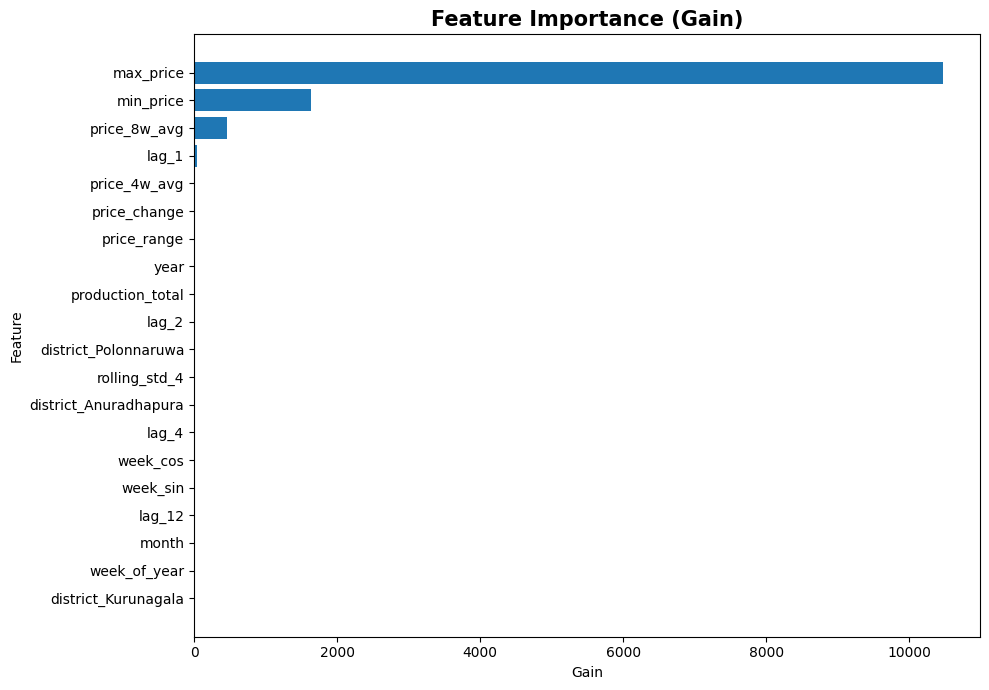

In [25]:
plt.figure(figsize=(10,7))

plt.barh(
    gain_df["Feature"],
    gain_df["Gain"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Importance (Gain)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gain")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance_gain.png"
    ),
    dpi=300
)

plt.show()

**Weight Plot**

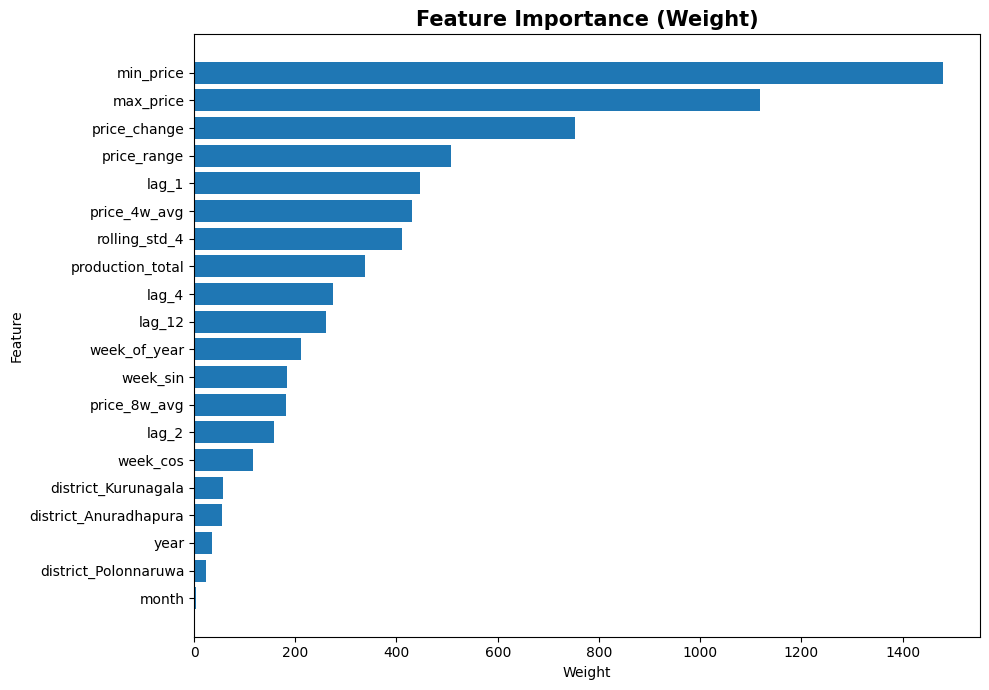

In [26]:
plt.figure(figsize=(10,7))

plt.barh(
    weight_df["Feature"],
    weight_df["Weight"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Importance (Weight)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weight")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance_weight.png"
    ),
    dpi=300
)

plt.show()

**Cover Plot**

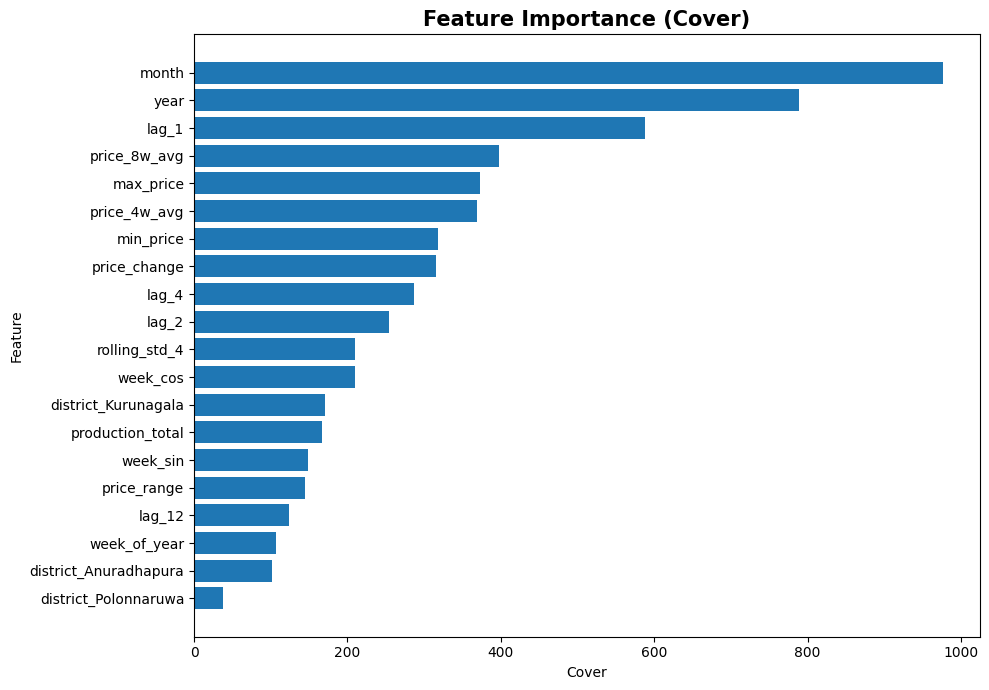

In [27]:
plt.figure(figsize=(10,7))

plt.barh(
    cover_df["Feature"],
    cover_df["Cover"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Importance (Cover)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cover")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance_cover.png"
    ),
    dpi=300
)

plt.show()

**Combined Importance Table**

In [28]:
importance_df = gain_df.merge(
    weight_df,
    on="Feature",
    how="outer"
)

importance_df = importance_df.merge(
    cover_df,
    on="Feature",
    how="outer"
)

importance_df = importance_df.fillna(0)

display(importance_df)

,Feature,Gain,Gain (%),Weight,Weight (%),Cover,Cover (%)
0,district_Anuradhapura,0.517201,0.004093,56.0,0.795229,101.089287,1.660610
1,district_Kurunagala,0.266548,0.002109,58.0,0.823630,170.689651,2.803947
2,district_Polonnaruwa,0.549109,0.004345,24.0,0.340812,38.000000,0.624232
3,lag_1,44.169956,0.349511,446.0,6.333428,587.598633,9.652580
4,lag_12,0.468998,0.003711,260.0,3.692133,124.338463,2.042528
5,lag_2,0.556907,0.004407,158.0,2.243681,254.291138,4.177283
6,lag_4,0.516085,0.004084,274.0,3.890940,286.335754,4.703685
7,max_price,10466.889648,82.823104,1118.0,15.876172,372.938293,6.126319
8,min_price,1641.651245,12.990168,1479.0,21.002556,318.223785,5.227515
9,month,0.322164,0.002549,4.0,0.056802,976.000000,16.032913


**Save Results**

In [29]:
importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance.csv"
    ),
    index=False
)

print("Feature importance table saved successfully.")

Feature importance table saved successfully.


**Top 10 Features**

In [30]:
top10 = gain_df.head(10)

print("=" * 60)
print("Top 10 Most Important Features")
print("=" * 60)

display(top10)

Top 10 Most Important Features


,Feature,Gain,Gain (%)
0,max_price,10466.889648,82.823104
1,min_price,1641.651245,12.990168
2,price_8w_avg,459.224030,3.633779
3,lag_1,44.169956,0.349511
4,price_4w_avg,17.156765,0.135759
5,price_change,1.284435,0.010164
6,price_range,0.902109,0.007138
7,year,0.660005,0.005223
8,production_total,0.647310,0.005122
9,lag_2,0.556907,0.004407


**Feature Ranking Table**

In [31]:
ranking_df = importance_df.copy()

ranking_df = ranking_df.sort_values(
    by="Gain",
    ascending=False
).reset_index(drop=True)

ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))

ranking_df = ranking_df[
    [
        "Rank",
        "Feature",
        "Gain",
        "Gain (%)",
        "Weight",
        "Weight (%)",
        "Cover",
        "Cover (%)"
    ]
]

display(ranking_df)

,Rank,Feature,Gain,Gain (%),Weight,Weight (%),Cover,Cover (%)
0,1,max_price,10466.889648,82.823104,1118.0,15.876172,372.938293,6.126319
1,2,min_price,1641.651245,12.990168,1479.0,21.002556,318.223785,5.227515
2,3,price_8w_avg,459.224030,3.633779,181.0,2.570293,397.928162,6.536832
3,4,lag_1,44.169956,0.349511,446.0,6.333428,587.598633,9.652580
4,5,price_4w_avg,17.156765,0.135759,430.0,6.106220,368.932556,6.060516
5,6,price_change,1.284435,0.010164,752.0,10.678784,315.718079,5.186353
6,7,price_range,0.902109,0.007138,508.0,7.213860,144.190948,2.368649
7,8,year,0.660005,0.005223,35.0,0.497018,789.257141,12.965258
8,9,production_total,0.647310,0.005122,337.0,4.785572,166.866470,2.741143
9,10,lag_2,0.556907,0.004407,158.0,2.243681,254.291138,4.177283


**Publication Quality Top 10 Gain Chart**

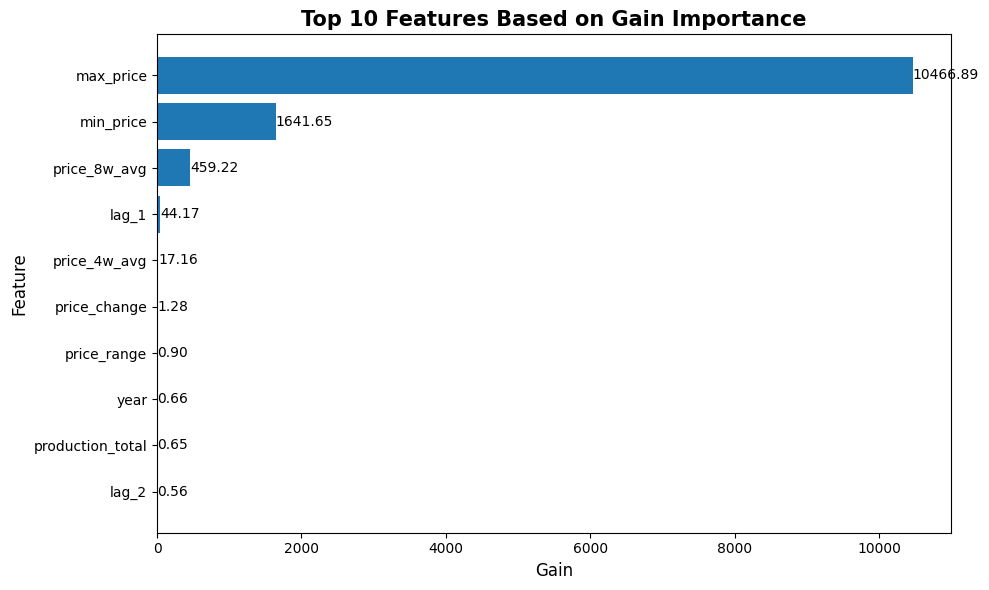

In [32]:
top10 = ranking_df.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10["Feature"],
    top10["Gain"]
)

plt.gca().invert_yaxis()

plt.xlabel("Gain", fontsize=12)

plt.ylabel("Feature", fontsize=12)

plt.title(
    "Top 10 Features Based on Gain Importance",
    fontsize=15,
    fontweight="bold"
)

# Add values
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va='center',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "top10_gain_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Gain Percentange Chart**

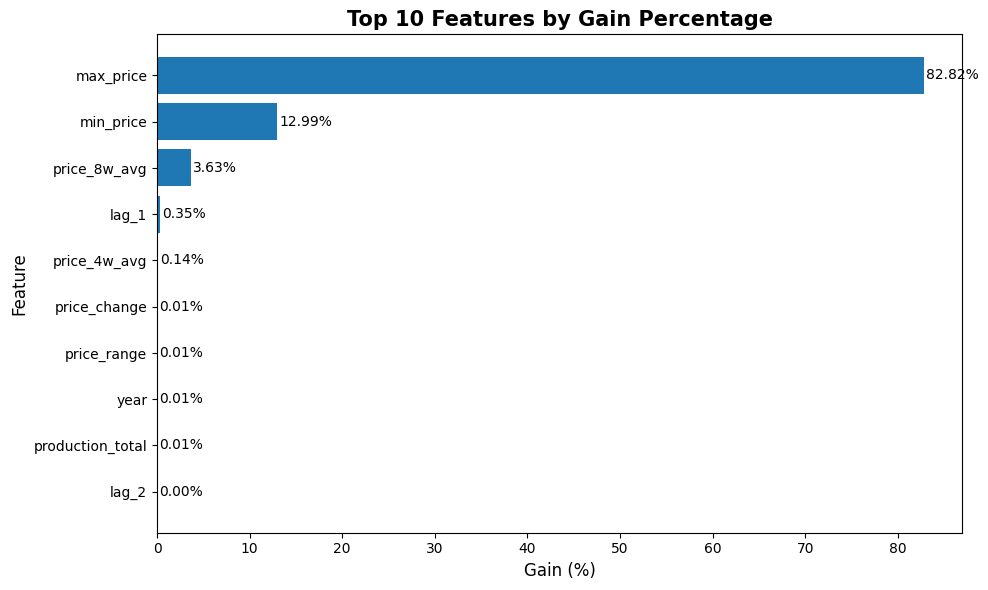

In [33]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top10["Feature"],
    top10["Gain (%)"]
)

plt.gca().invert_yaxis()

plt.xlabel("Gain (%)", fontsize=12)

plt.ylabel("Feature", fontsize=12)

plt.title(
    "Top 10 Features by Gain Percentage",
    fontsize=15,
    fontweight="bold"
)

for bar in bars:

    plt.text(
        bar.get_width()+0.2,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va='center',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "top10_gain_percentage.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Importance Summary**

In [34]:
print("="*70)
print("FEATURE IMPORTANCE SUMMARY")
print("="*70)

print(f"Total Features              : {len(ranking_df)}")

print(f"Highest Gain Feature        : {ranking_df.iloc[0]['Feature']}")

print(f"Highest Gain (%)            : {ranking_df.iloc[0]['Gain (%)']:.2f}%")

print(f"Highest Weight Feature      : {weight_df.iloc[0]['Feature']}")

print(f"Highest Cover Feature       : {cover_df.iloc[0]['Feature']}")

print("\nTop Five Gain Features")

display(
    ranking_df[
        [
            "Rank",
            "Feature",
            "Gain (%)"
        ]
    ].head()
)

FEATURE IMPORTANCE SUMMARY
Total Features              : 20
Highest Gain Feature        : max_price
Highest Gain (%)            : 82.82%
Highest Weight Feature      : min_price
Highest Cover Feature       : month

Top Five Gain Features


,Rank,Feature,Gain (%)
0,1,max_price,82.823104
1,2,min_price,12.990168
2,3,price_8w_avg,3.633779
3,4,lag_1,0.349511
4,5,price_4w_avg,0.135759


**Export Thesis Table**

In [35]:
ranking_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "feature_ranking.csv"
    ),
    index=False
)

top10.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "top10_gain_features.csv"
    ),
    index=False
)

print("Tables exported successfully.")

Tables exported successfully.


**Create Feature Ranking Comparison**

In [36]:
# Rank by Gain
gain_rank = gain_df.copy()
gain_rank["Gain Rank"] = gain_rank["Gain"].rank(
    ascending=False,
    method="min"
).astype(int)

# Rank by Weight
weight_rank = weight_df.copy()
weight_rank["Weight Rank"] = weight_rank["Weight"].rank(
    ascending=False,
    method="min"
).astype(int)

# Rank by Cover
cover_rank = cover_df.copy()
cover_rank["Cover Rank"] = cover_df["Cover"].rank(
    ascending=False,
    method="min"
).astype(int)

# Merge
ranking_compare = (
    gain_rank[["Feature","Gain Rank"]]
    .merge(
        weight_rank[["Feature","Weight Rank"]],
        on="Feature",
        how="outer"
    )
    .merge(
        cover_rank[["Feature","Cover Rank"]],
        on="Feature",
        how="outer"
    )
)

ranking_compare = ranking_compare.fillna(len(feature_names)+1)

ranking_compare[
    ["Gain Rank","Weight Rank","Cover Rank"]
] = ranking_compare[
    ["Gain Rank","Weight Rank","Cover Rank"]
].astype(int)

display(ranking_compare.sort_values("Gain Rank"))

,Feature,Gain Rank,Weight Rank,Cover Rank
7,max_price,1,2,5
8,min_price,2,1,7
11,price_8w_avg,3,13,4
3,lag_1,4,5,3
10,price_4w_avg,5,6,6
12,price_change,6,3,8
13,price_range,7,4,16
19,year,8,18,2
14,production_total,9,8,14
5,lag_2,10,14,10


**Overall Importance Score**

In [37]:
ranking_compare["Average Rank"] = (

    ranking_compare["Gain Rank"] +

    ranking_compare["Weight Rank"] +

    ranking_compare["Cover Rank"]

) / 3

ranking_compare = ranking_compare.sort_values(
    by="Average Rank"
)

ranking_compare.insert(
    0,
    "Overall Rank",
    range(1,len(ranking_compare)+1)
)

display(ranking_compare)

,Overall Rank,Feature,Gain Rank,Weight Rank,Cover Rank,Average Rank
7,1,max_price,1,2,5,2.666667
8,2,min_price,2,1,7,3.333333
3,3,lag_1,4,5,3,4.000000
10,4,price_4w_avg,5,6,6,5.666667
12,5,price_change,6,3,8,5.666667
11,6,price_8w_avg,3,13,4,6.666667
13,7,price_range,7,4,16,9.000000
19,8,year,8,18,2,9.333333
15,9,rolling_std_4,12,7,11,10.000000
14,10,production_total,9,8,14,10.333333


**Research Observation**

In [38]:
def observation(row):

    if row["Average Rank"] <= 3:
        return "Highly Influential"

    elif row["Average Rank"] <= 8:
        return "Moderately Influential"

    else:
        return "Supporting Feature"


ranking_compare["Observation"] = ranking_compare.apply(
    observation,
    axis=1
)

display(ranking_compare)

,Overall Rank,Feature,Gain Rank,Weight Rank,Cover Rank,Average Rank,Observation
7,1,max_price,1,2,5,2.666667,Highly Influential
8,2,min_price,2,1,7,3.333333,Moderately Influential
3,3,lag_1,4,5,3,4.000000,Moderately Influential
10,4,price_4w_avg,5,6,6,5.666667,Moderately Influential
12,5,price_change,6,3,8,5.666667,Moderately Influential
11,6,price_8w_avg,3,13,4,6.666667,Moderately Influential
13,7,price_range,7,4,16,9.000000,Supporting Feature
19,8,year,8,18,2,9.333333,Supporting Feature
15,9,rolling_std_4,12,7,11,10.000000,Supporting Feature
14,10,production_total,9,8,14,10.333333,Supporting Feature


**Save Comparison Table**

In [39]:
ranking_compare.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "feature_ranking_comparison.csv"

    ),

    index=False

)

print("Comparison table saved successfully.")

Comparison table saved successfully.


**Publication Quality Table**

In [40]:
display(

    ranking_compare.head(15)

)

,Overall Rank,Feature,Gain Rank,Weight Rank,Cover Rank,Average Rank,Observation
7,1,max_price,1,2,5,2.666667,Highly Influential
8,2,min_price,2,1,7,3.333333,Moderately Influential
3,3,lag_1,4,5,3,4.000000,Moderately Influential
10,4,price_4w_avg,5,6,6,5.666667,Moderately Influential
12,5,price_change,6,3,8,5.666667,Moderately Influential
11,6,price_8w_avg,3,13,4,6.666667,Moderately Influential
13,7,price_range,7,4,16,9.000000,Supporting Feature
19,8,year,8,18,2,9.333333,Supporting Feature
15,9,rolling_std_4,12,7,11,10.000000,Supporting Feature
14,10,production_total,9,8,14,10.333333,Supporting Feature


**Create Correlation Dataset**

In [41]:
corr_df = df.copy()

# Remove non-numeric columns
corr_df = corr_df.drop(
    columns=[
        "date",
        "district",
        "paddy_type"
    ]
)

print("=" * 60)
print("Correlation Dataset")
print("=" * 60)

print("Shape:", corr_df.shape)

display(corr_df.head())

Correlation Dataset
Shape: (2308, 27)


,min_price,max_price,avg_price,production_total,price_range,week_of_year,week_sin,week_cos,price_t-1,price_t-2,...,year,month,week,lag_1,lag_2,lag_4,lag_12,rolling_mean_4,rolling_std_4,season_Yala
0,34.0,40.0,37.14,307661,6.0,13,1.000000,-1.608123e-16,37.48,38.50,...,2015,3,13,37.48,38.50,36.34,27.50,37.6575,0.586195,False
1,34.0,40.0,36.40,309335,6.0,14,0.992709,-1.205367e-01,37.14,37.48,...,2015,4,14,37.14,37.48,37.51,26.10,37.3800,0.872238,True
2,34.0,39.0,35.68,309335,5.0,15,0.970942,-2.393157e-01,36.40,37.14,...,2015,4,15,36.40,37.14,38.50,26.58,36.6750,0.802060,True
3,31.0,37.0,34.97,309335,6.0,16,0.935016,-3.546049e-01,35.68,36.40,...,2015,4,16,35.68,36.40,37.48,28.95,36.0475,0.933430,True
4,30.0,38.0,34.03,309335,8.0,17,0.885456,-4.647232e-01,34.97,35.68,...,2015,4,17,34.97,35.68,37.14,30.64,35.2700,1.012028,True


In [42]:
corr_df = df.copy()

# Remove non-numeric / unused columns
drop_columns = [
    "date",
    "district",
    "paddy_type",
    "price_t-1",
    "price_t-2",
    "price_t-3",
    "price_t-4",
    "price_t-8",
    "price_t-12"
]

corr_df = corr_df.drop(columns=drop_columns)

print("="*60)
print("Correlation Dataset")
print("="*60)

print("Shape :", corr_df.shape)

display(corr_df.head())

Correlation Dataset
Shape : (2308, 21)


,min_price,max_price,avg_price,production_total,price_range,week_of_year,week_sin,week_cos,price_4w_avg,price_8w_avg,...,year,month,week,lag_1,lag_2,lag_4,lag_12,rolling_mean_4,rolling_std_4,season_Yala
0,34.0,40.0,37.14,307661,6.0,13,1.000000,-1.608123e-16,37.6575,35.88125,...,2015,3,13,37.48,38.50,36.34,27.50,37.6575,0.586195,False
1,34.0,40.0,36.40,309335,6.0,14,0.992709,-1.205367e-01,37.3800,36.40875,...,2015,4,14,37.14,37.48,37.51,26.10,37.3800,0.872238,True
2,34.0,39.0,35.68,309335,5.0,15,0.970942,-2.393157e-01,36.6750,36.70250,...,2015,4,15,36.40,37.14,38.50,26.58,36.6750,0.802060,True
3,31.0,37.0,34.97,309335,6.0,16,0.935016,-3.546049e-01,36.0475,36.75250,...,2015,4,16,35.68,36.40,37.48,28.95,36.0475,0.933430,True
4,30.0,38.0,34.03,309335,8.0,17,0.885456,-4.647232e-01,35.2700,36.46375,...,2015,4,17,34.97,35.68,37.14,30.64,35.2700,1.012028,True


**Calculate Peasrson Correlation Matrix**

In [43]:
correlation_matrix = corr_df.corr(method="pearson")

print("=" * 60)
print("Correlation Matrix")
print("=" * 60)

display(correlation_matrix.round(3))

Correlation Matrix


,min_price,max_price,avg_price,production_total,price_range,week_of_year,week_sin,week_cos,price_4w_avg,price_8w_avg,...,year,month,week,lag_1,lag_2,lag_4,lag_12,rolling_mean_4,rolling_std_4,season_Yala
min_price,1.000,0.992,0.998,0.151,0.154,0.034,-0.022,0.064,0.992,0.984,...,0.876,0.034,0.034,0.992,0.986,0.975,0.941,0.992,0.320,-0.052
max_price,0.992,1.000,0.998,0.159,0.277,0.009,-0.002,0.073,0.995,0.991,...,0.894,0.008,0.009,0.994,0.990,0.982,0.955,0.995,0.346,-0.061
avg_price,0.998,0.998,1.000,0.153,0.220,0.022,-0.013,0.069,0.996,0.990,...,0.886,0.021,0.022,0.995,0.990,0.981,0.950,0.996,0.333,-0.056
production_total,0.151,0.159,0.153,1.000,0.093,0.039,-0.051,0.358,0.159,0.167,...,0.270,0.032,0.039,0.156,0.160,0.167,0.204,0.159,-0.025,-0.399
price_range,0.154,0.277,0.220,0.093,1.000,-0.187,0.153,0.087,0.239,0.263,...,0.334,-0.193,-0.187,0.230,0.245,0.270,0.312,0.239,0.272,-0.081
week_of_year,0.034,0.009,0.022,0.039,-0.187,1.000,-0.774,0.056,0.008,-0.008,...,-0.108,0.996,1.000,0.012,0.002,-0.014,-0.055,0.008,-0.187,-0.129
week_sin,-0.022,-0.002,-0.013,-0.051,0.153,-0.774,1.000,-0.000,-0.007,0.002,...,0.078,-0.776,-0.774,-0.009,-0.005,0.004,0.032,-0.007,0.079,0.179
week_cos,0.064,0.073,0.069,0.358,0.087,0.056,-0.000,1.000,0.071,0.072,...,0.060,0.053,0.056,0.071,0.072,0.073,0.059,0.071,0.137,-0.863
price_4w_avg,0.992,0.995,0.996,0.159,0.239,0.008,-0.007,0.071,1.000,0.997,...,0.890,0.007,0.008,0.998,0.998,0.991,0.959,1.000,0.334,-0.055
price_8w_avg,0.984,0.991,0.990,0.167,0.263,-0.008,0.002,0.072,0.997,1.000,...,0.894,-0.010,-0.008,0.993,0.995,0.997,0.969,0.997,0.337,-0.056


**Full** Correlation Heatmap

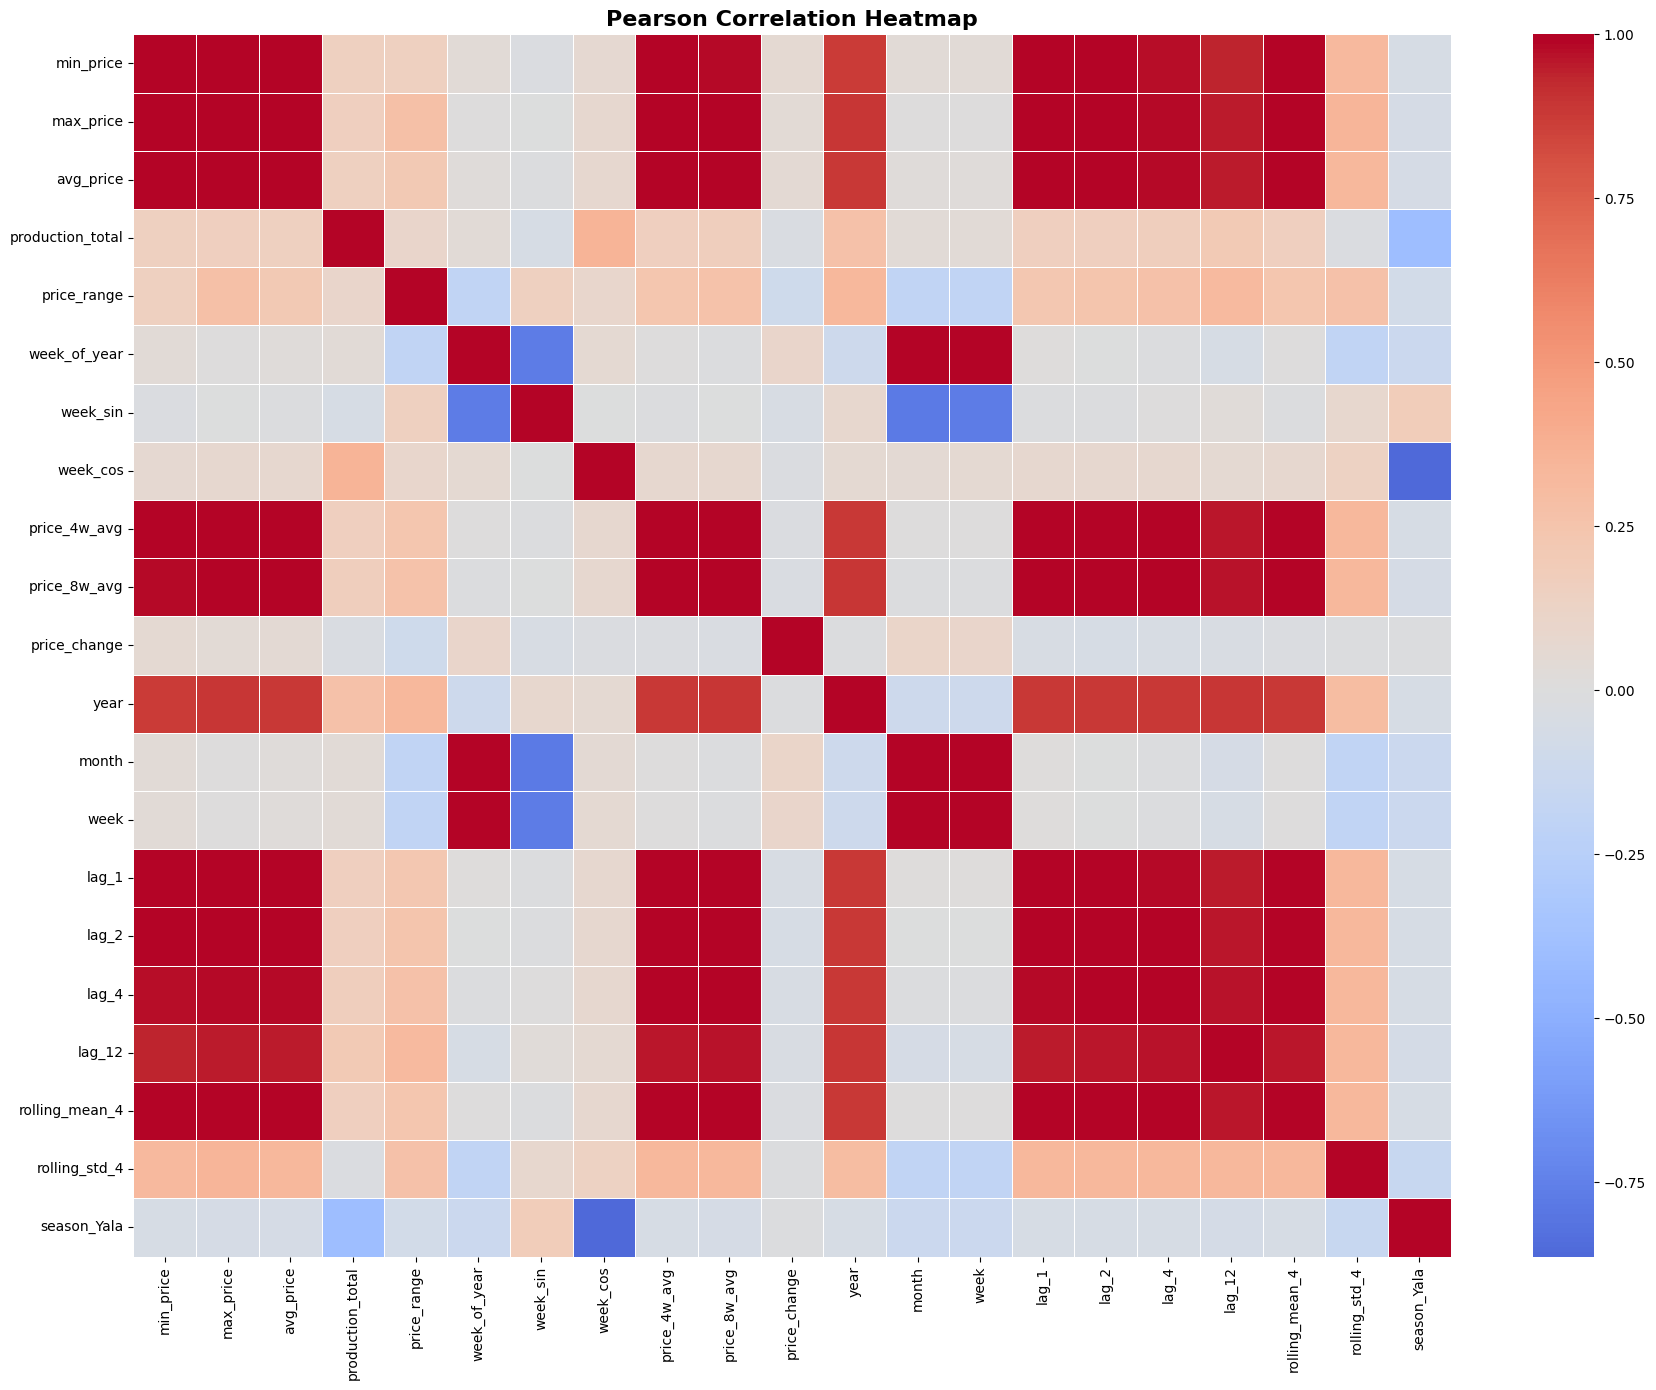

In [44]:
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title(
    "Pearson Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Correlation with Target Variable 43**

In [45]:
target_corr = (
    correlation_matrix["avg_price"]
    .drop("avg_price")
    .sort_values(ascending=False)
)

target_corr_df = pd.DataFrame({
    "Feature": target_corr.index,
    "Correlation": target_corr.values
})

display(target_corr_df)

,Feature,Correlation
0,max_price,0.998065
1,min_price,0.997502
2,rolling_mean_4,0.995686
3,price_4w_avg,0.995686
4,lag_1,0.995340
5,lag_2,0.989977
6,price_8w_avg,0.989698
7,lag_4,0.980759
8,lag_12,0.950130
9,year,0.886307


**Publication Quality Target Correlation Plot**

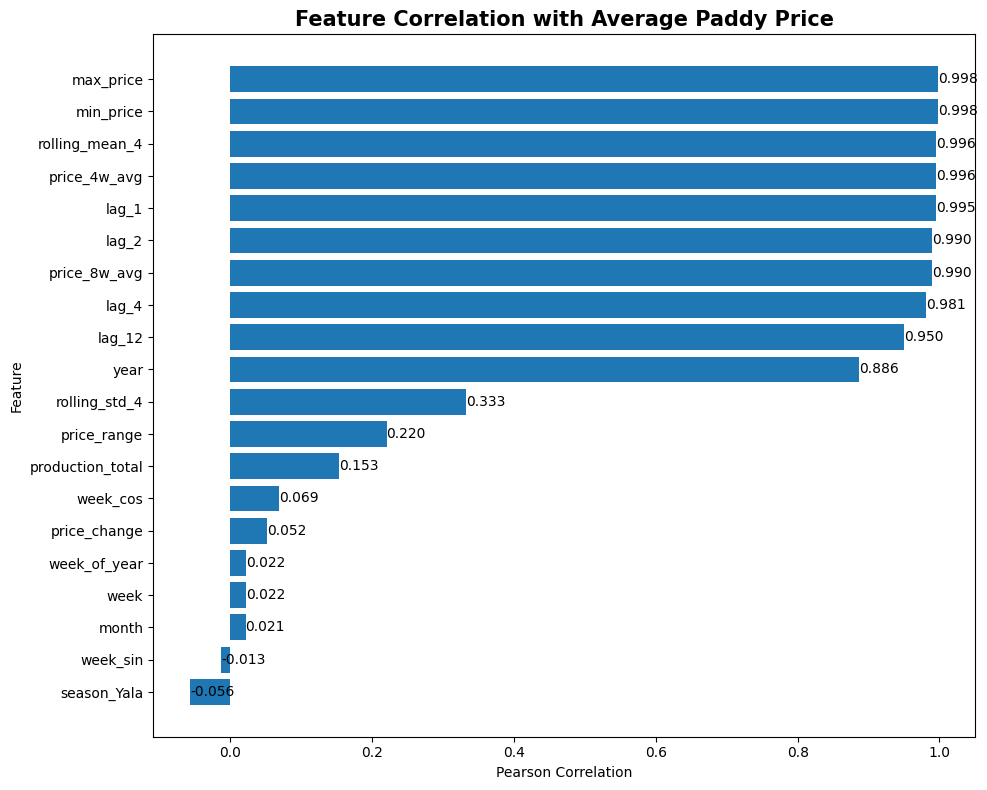

In [46]:
plt.figure(figsize=(10,8))

bars = plt.barh(
    target_corr_df["Feature"],
    target_corr_df["Correlation"]
)

plt.gca().invert_yaxis()

plt.xlabel("Pearson Correlation")

plt.ylabel("Feature")

plt.title(
    "Feature Correlation with Average Paddy Price",
    fontsize=15,
    fontweight="bold"
)

for bar in bars:

    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "target_correlation.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Strong Positive Correlations**

In [47]:
positive_corr = target_corr_df[
    target_corr_df["Correlation"] > 0
].sort_values(
    by="Correlation",
    ascending=False
)

print("="*60)
print("Positive Correlations")
print("="*60)

display(positive_corr)

Positive Correlations


,Feature,Correlation
0,max_price,0.998065
1,min_price,0.997502
2,rolling_mean_4,0.995686
3,price_4w_avg,0.995686
4,lag_1,0.995340
5,lag_2,0.989977
6,price_8w_avg,0.989698
7,lag_4,0.980759
8,lag_12,0.950130
9,year,0.886307


**Strong Negative Correlations**

In [48]:
negative_corr = target_corr_df[
    target_corr_df["Correlation"] < 0
].sort_values(
    by="Correlation"
)

print("="*60)
print("Negative Correlations")
print("="*60)

display(negative_corr)

Negative Correlations


,Feature,Correlation
19,season_Yala,-0.056410
18,week_sin,-0.012616


**Detect Multicollinearity**

In [49]:
threshold = 0.90

multicollinear_pairs = []

corr = correlation_matrix.abs()

for i in range(len(corr.columns)):

    for j in range(i):

        if corr.iloc[i, j] >= threshold:

            multicollinear_pairs.append([

                corr.columns[i],

                corr.columns[j],

                corr.iloc[i, j]

            ])

multi_df = pd.DataFrame(

    multicollinear_pairs,

    columns=[

        "Feature 1",

        "Feature 2",

        "Correlation"

    ]

)

multi_df = multi_df.sort_values(

    by="Correlation",

    ascending=False

)

display(multi_df)

,Feature 1,Feature 2,Correlation
11,week,week_of_year,1.000000
42,rolling_mean_4,price_4w_avg,1.000000
16,lag_1,price_4w_avg,0.998211
44,rolling_mean_4,lag_1,0.998211
21,lag_2,price_4w_avg,0.998209
45,rolling_mean_4,lag_2,0.998209
2,avg_price,max_price,0.998065
1,avg_price,min_price,0.997502
43,rolling_mean_4,price_8w_avg,0.996745
9,price_8w_avg,price_4w_avg,0.996745


**Export Correlation Results**

In [50]:
target_corr_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "target_correlation.csv"
    ),
    index=False
)

multi_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "multicollinearity.csv"
    ),
    index=False
)

print("Correlation results saved successfully.")

Correlation results saved successfully.


**Research Summary**

In [51]:
print("="*70)
print("CORRELATION ANALYSIS SUMMARY")
print("="*70)

print(f"Highest Positive Correlation : {positive_corr.iloc[0]['Feature']}")
print(f"Coefficient                  : {positive_corr.iloc[0]['Correlation']:.3f}")

print()

if len(negative_corr) > 0:

    print(f"Strongest Negative Correlation : {negative_corr.iloc[0]['Feature']}")
    print(f"Coefficient                    : {negative_corr.iloc[0]['Correlation']:.3f}")

print()

print(f"Highly Correlated Feature Pairs (>|0.90|): {len(multi_df)}")

CORRELATION ANALYSIS SUMMARY
Highest Positive Correlation : max_price
Coefficient                  : 0.998

Strongest Negative Correlation : season_Yala
Coefficient                    : -0.056

Highly Correlated Feature Pairs (>|0.90|): 48


**Create SHAP Explainer 50**

In [52]:
import shap

print("="*60)
print("Creating SHAP Explainer...")
print("="*60)

explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully.")

Creating SHAP Explainer...
SHAP TreeExplainer created successfully.


**Calculate SHAP Values**

In [53]:
print("="*60)
print("Calculating SHAP Values...")
print("="*60)

shap_values = explainer.shap_values(X)

print("SHAP values calculated successfully.")

Calculating SHAP Values...
SHAP values calculated successfully.


**Verify SHAP Values**

In [54]:
print("="*60)
print("SHAP Verification")
print("="*60)

print("Feature Matrix Shape :", X.shape)

print("SHAP Matrix Shape    :", shap_values.shape)

print("Number of Features   :", X.shape[1])

print("Number of Samples    :", X.shape[0])

SHAP Verification
Feature Matrix Shape : (2308, 23)
SHAP Matrix Shape    : (2308, 23)
Number of Features   : 23
Number of Samples    : 2308


**SHAP Summary Plot**

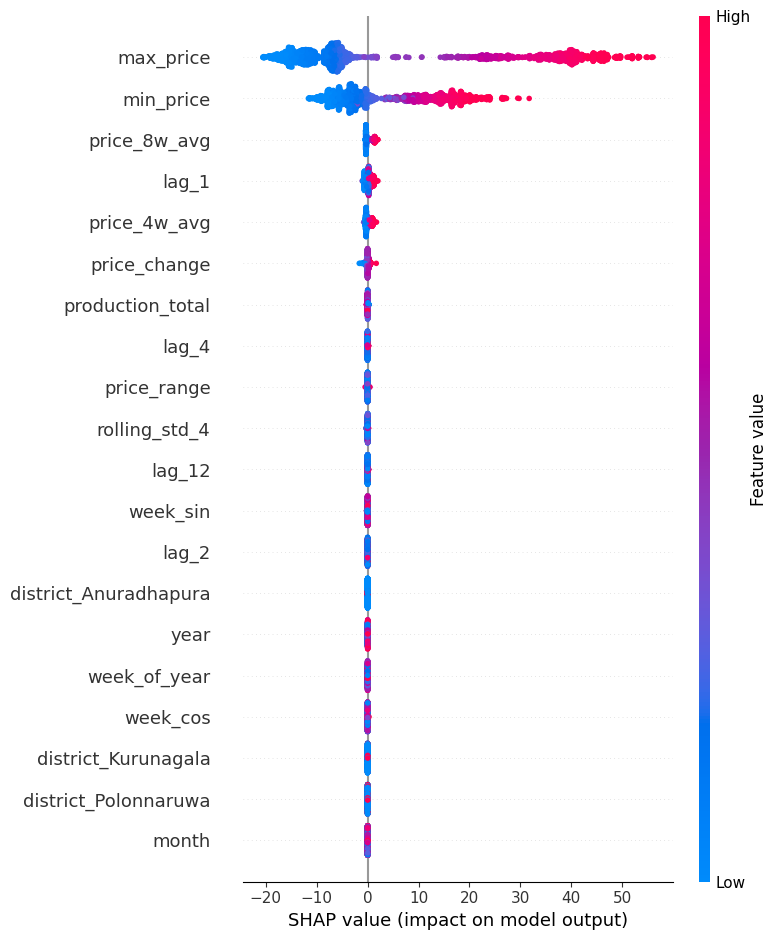

In [55]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "shap_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**SHAP Bar Plot**

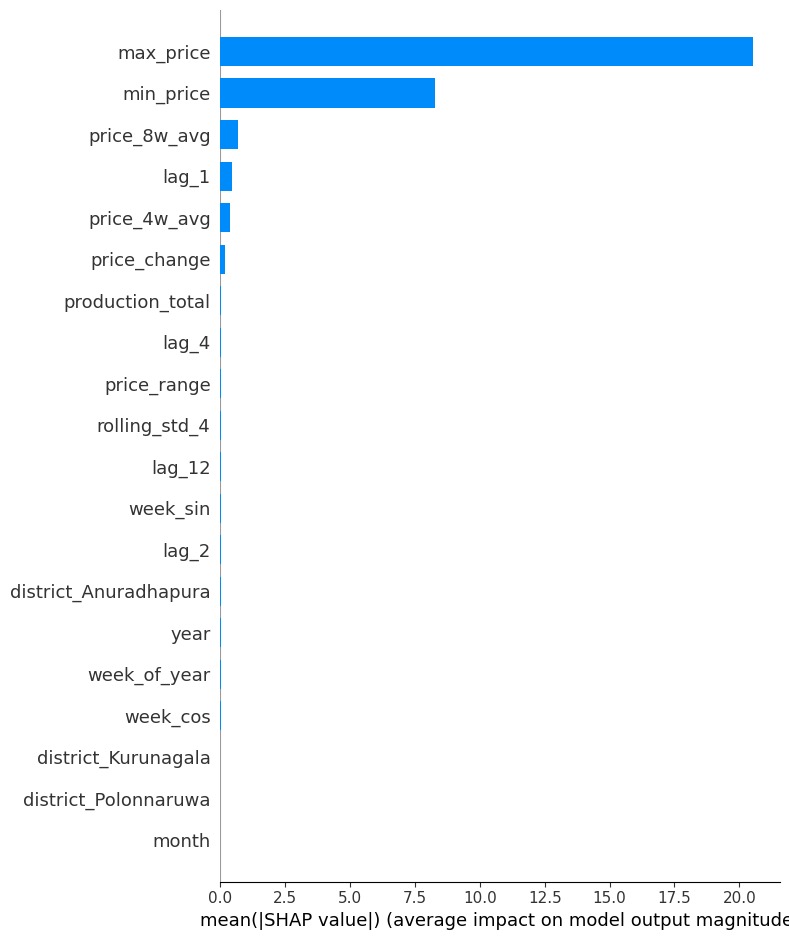

In [56]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "shap_bar.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Mean Absolute SHAP Values**

In [57]:
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({

    "Feature": X.columns,

    "Mean SHAP Value": mean_shap

})

shap_df = shap_df.sort_values(

    by="Mean SHAP Value",

    ascending=False

).reset_index(drop=True)

display(shap_df)

,Feature,Mean SHAP Value
0,max_price,20.539101
1,min_price,8.267990
2,price_8w_avg,0.682698
3,lag_1,0.457797
4,price_4w_avg,0.379126
5,price_change,0.161553
6,production_total,0.032304
7,lag_4,0.028538
8,price_range,0.021107
9,rolling_std_4,0.020172


**SHAP Ranking**

In [58]:
shap_df.insert(

    0,

    "Rank",

    range(1,len(shap_df)+1)

)

display(shap_df)

,Rank,Feature,Mean SHAP Value
0,1,max_price,20.539101
1,2,min_price,8.267990
2,3,price_8w_avg,0.682698
3,4,lag_1,0.457797
4,5,price_4w_avg,0.379126
5,6,price_change,0.161553
6,7,production_total,0.032304
7,8,lag_4,0.028538
8,9,price_range,0.021107
9,10,rolling_std_4,0.020172


**Compare SHAP vs Gain**

In [59]:
comparison = pd.merge(

    gain_df[["Feature","Gain (%)"]],

    shap_df[["Feature","Mean SHAP Value"]],

    on="Feature"

)

comparison = comparison.sort_values(

    by="Mean SHAP Value",

    ascending=False

)

display(comparison)

,Feature,Gain (%),Mean SHAP Value
0,max_price,82.823104,20.539101
1,min_price,12.990168,8.267990
2,price_8w_avg,3.633779,0.682698
3,lag_1,0.349511,0.457797
4,price_4w_avg,0.135759,0.379126
5,price_change,0.010164,0.161553
8,production_total,0.005122,0.032304
13,lag_4,0.004084,0.028538
6,price_range,0.007138,0.021107
11,rolling_std_4,0.004271,0.020172


**SHAP Results**

In [60]:
shap_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "shap_importance.csv"

    ),

    index=False

)

comparison.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "shap_vs_gain.csv"

    ),

    index=False

)

print("SHAP results saved successfully.")

SHAP results saved successfully.


**SHAP Summary**

In [61]:
print("="*70)
print("GLOBAL SHAP SUMMARY")
print("="*70)

print(f"Most Influential Feature : {shap_df.iloc[0]['Feature']}")

print(f"Mean SHAP Value          : {shap_df.iloc[0]['Mean SHAP Value']:.4f}")

print()

print("Top 10 SHAP Features")

display(shap_df.head(10))

GLOBAL SHAP SUMMARY
Most Influential Feature : max_price
Mean SHAP Value          : 20.5391

Top 10 SHAP Features


,Rank,Feature,Mean SHAP Value
0,1,max_price,20.539101
1,2,min_price,8.267990
2,3,price_8w_avg,0.682698
3,4,lag_1,0.457797
4,5,price_4w_avg,0.379126
5,6,price_change,0.161553
6,7,production_total,0.032304
7,8,lag_4,0.028538
8,9,price_range,0.021107
9,10,rolling_std_4,0.020172


**SHAP Dependence Plots**

<Figure size 800x600 with 0 Axes>

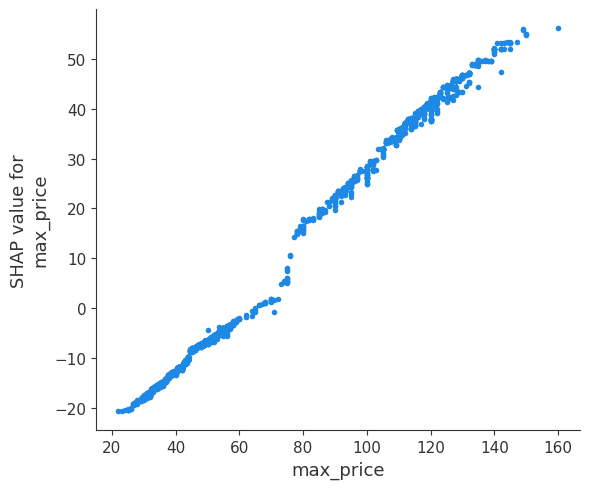

<Figure size 800x600 with 0 Axes>

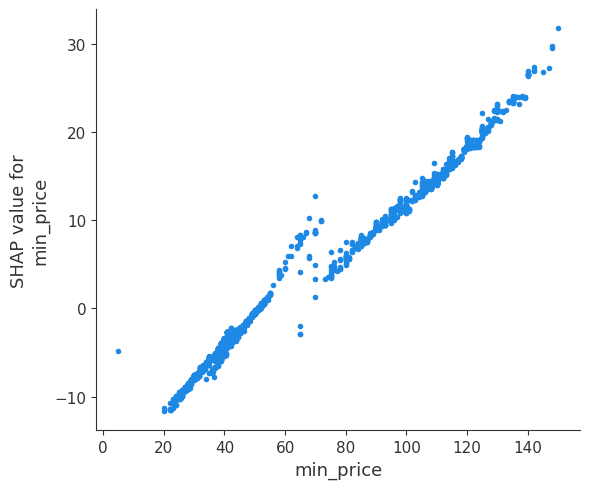

<Figure size 800x600 with 0 Axes>

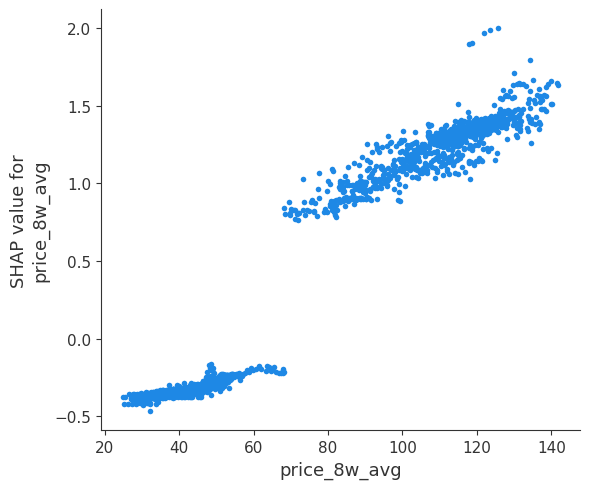

<Figure size 800x600 with 0 Axes>

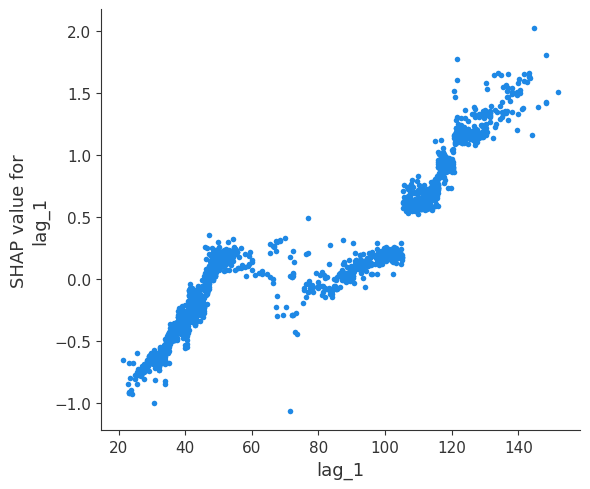

<Figure size 800x600 with 0 Axes>

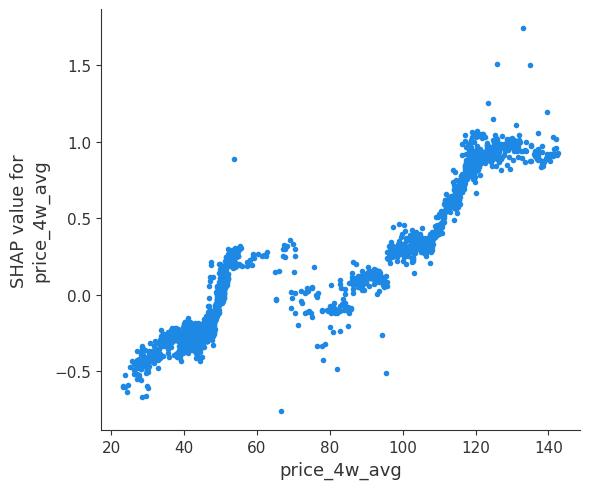

In [62]:
important_features = [
    "max_price",
    "min_price",
    "price_8w_avg",
    "lag_1",
    "price_4w_avg"
]

for feature in important_features:

    plt.figure(figsize=(8,6))

    shap.dependence_plot(
        feature,
        shap_values,
        X,
        interaction_index=None,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"dependence_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

**Compute SHAP Interaction Values**

In [63]:
print("="*60)
print("Computing SHAP Interaction Values...")
print("="*60)

interaction_values = explainer.shap_interaction_values(X)

print("Interaction values calculated.")

Computing SHAP Interaction Values...
Interaction values calculated.


**Interaction Summary Plot**

<Figure size 1200x800 with 0 Axes>

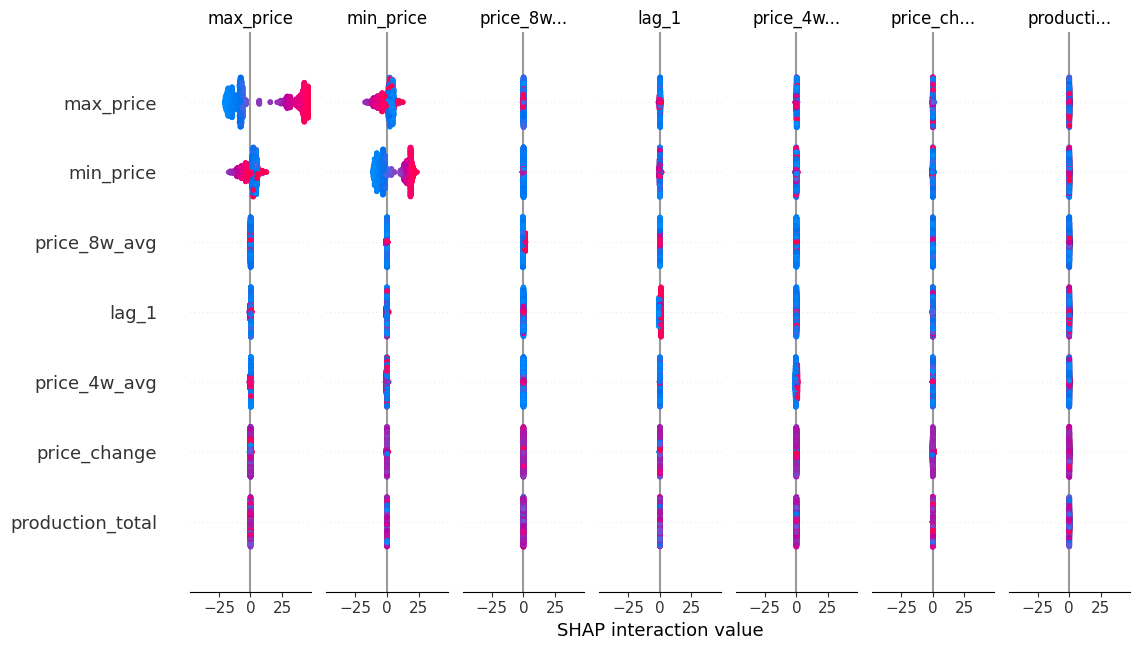

In [64]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    interaction_values,
    X,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "shap_interaction_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interaction Heatmap**

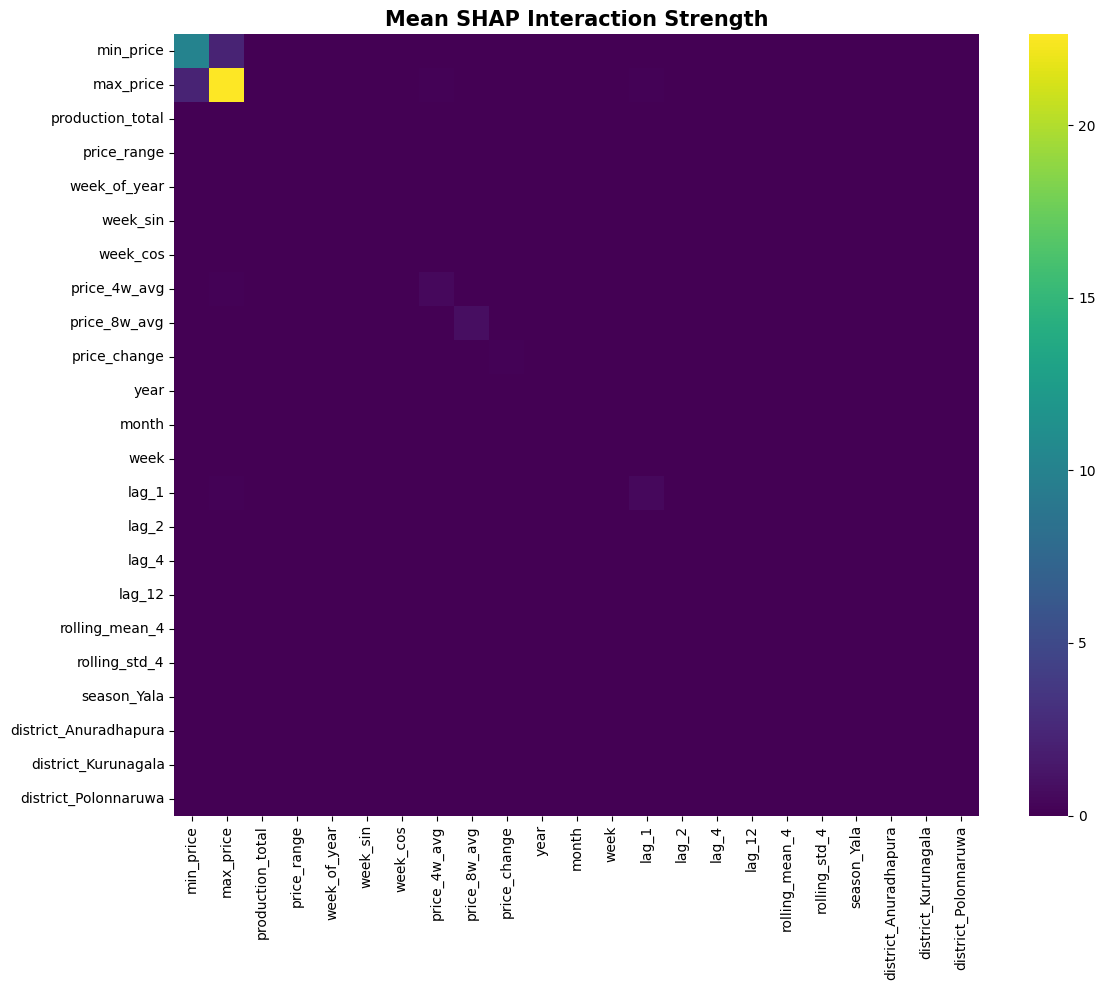

In [65]:
interaction_strength = np.abs(interaction_values).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_strength,
    index=X.columns,
    columns=X.columns
)

plt.figure(figsize=(12,10))

sns.heatmap(
    interaction_df,
    cmap="viridis"
)

plt.title(
    "Mean SHAP Interaction Strength",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "interaction_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Decision Plot**

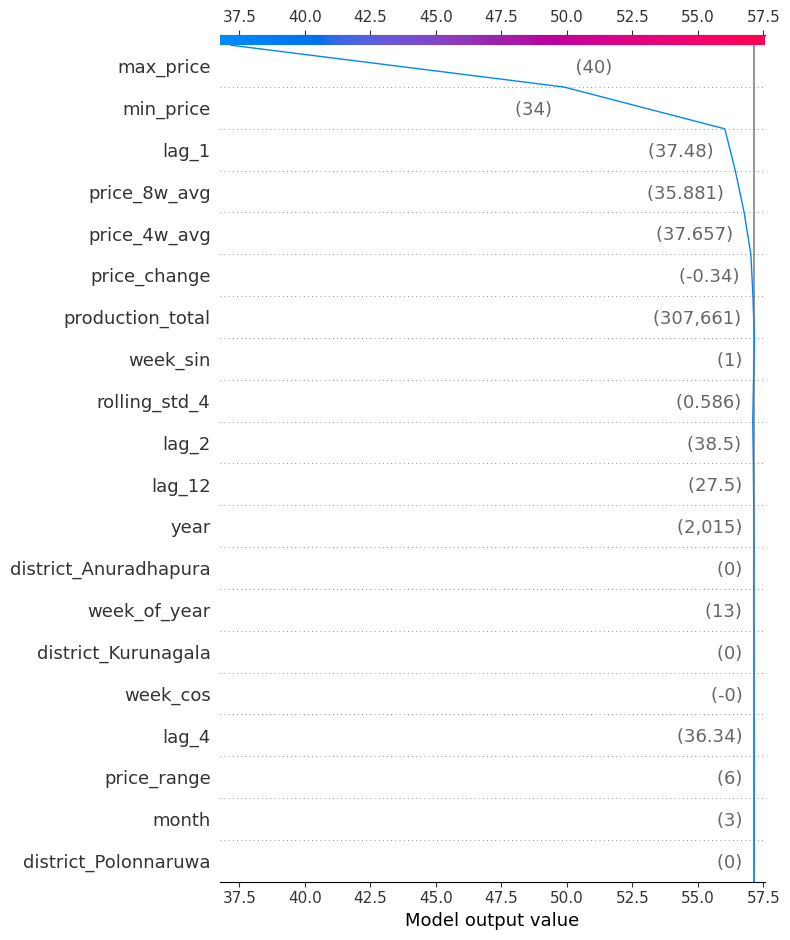

In [66]:
sample_index = 0

plt.figure(figsize=(12,6))

shap.decision_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X.iloc[sample_index],
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "decision_plot_sample0.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Export Interaction Matrix**

In [67]:
interaction_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "interaction_matrix.csv"
    )
)

print("Interaction matrix exported.")

Interaction matrix exported.


**Select Sample 64**

In [68]:
sample_index = 100

sample = X.iloc[[sample_index]]

sample_original = df.iloc[sample_index]

print("="*60)
print("Selected Sample")
print("="*60)

display(sample_original)

Selected Sample


,100
date,2017-02-23 00:00:00
district,Ampara
paddy_type,Long_Grain_White
min_price,36.0
max_price,38.0
avg_price,37.0
production_total,309733
price_range,2.0
week_of_year,8
week_sin,0.822984


**Prediction**

In [69]:
prediction = model.predict(sample)[0]

actual = df.iloc[sample_index]["avg_price"]

print("="*60)
print("Prediction")
print("="*60)

print(f"Actual Price     : {actual:.2f}")

print(f"Predicted Price  : {prediction:.2f}")

print(f"Difference       : {prediction-actual:.2f}")

Prediction
Actual Price     : 37.00
Predicted Price  : 37.05
Difference       : 0.05


**SHAP Waterfall Plot**

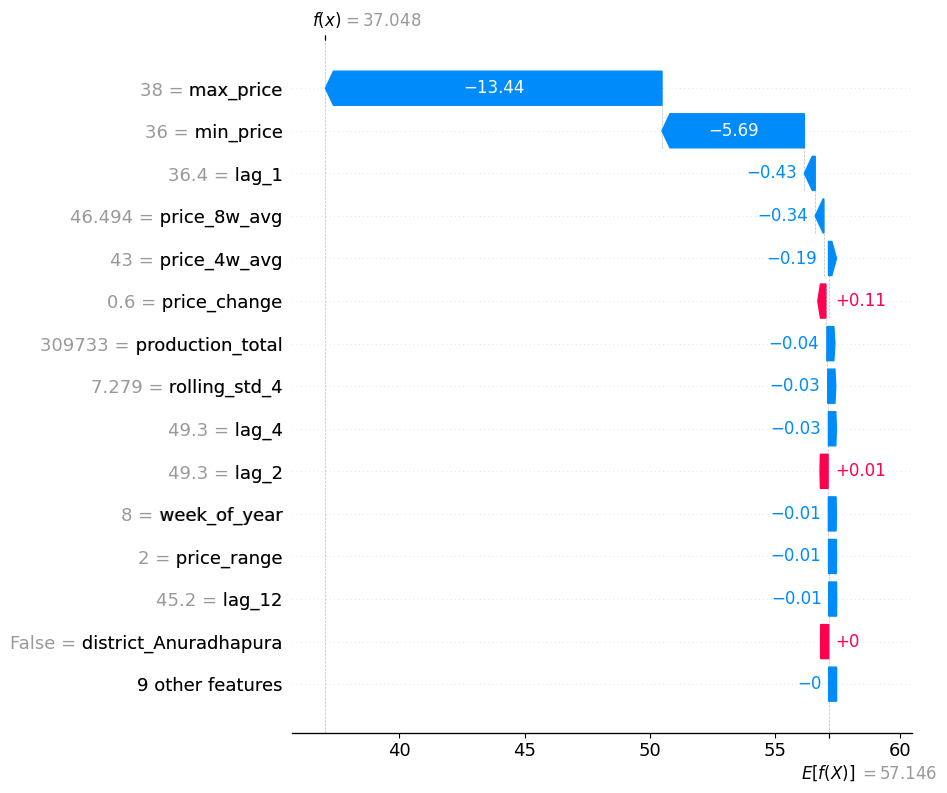

In [70]:
sample_shap = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=sample.values[0],
    feature_names=X.columns
)

plt.figure(figsize=(10,8))

shap.plots.waterfall(
    sample_shap,
    max_display=15,
    show=False
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "waterfall_sample.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**SHAP Force Plot**

In [71]:
shap.initjs()

force = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    sample
)

force

**Local Feature Contributions**

In [72]:
local_df = pd.DataFrame({

    "Feature": X.columns,

    "Feature Value": sample.values[0],

    "SHAP Contribution": shap_values[sample_index]

})

local_df["Absolute Contribution"] = local_df[
    "SHAP Contribution"
].abs()

local_df = local_df.sort_values(

    by="Absolute Contribution",

    ascending=False

)

display(local_df)

,Feature,Feature Value,SHAP Contribution,Absolute Contribution
1,max_price,38.0,-13.441557,13.441557
0,min_price,36.0,-5.686107,5.686107
13,lag_1,36.4,-0.434693,0.434693
8,price_8w_avg,46.49375,-0.344750,0.344750
7,price_4w_avg,43.0,-0.186478,0.186478
9,price_change,0.6,0.106876,0.106876
2,production_total,309733,-0.043650,0.043650
18,rolling_std_4,7.278736,-0.032733,0.032733
15,lag_4,49.3,-0.026741,0.026741
14,lag_2,49.3,0.014920,0.014920


**Feature Contribution**

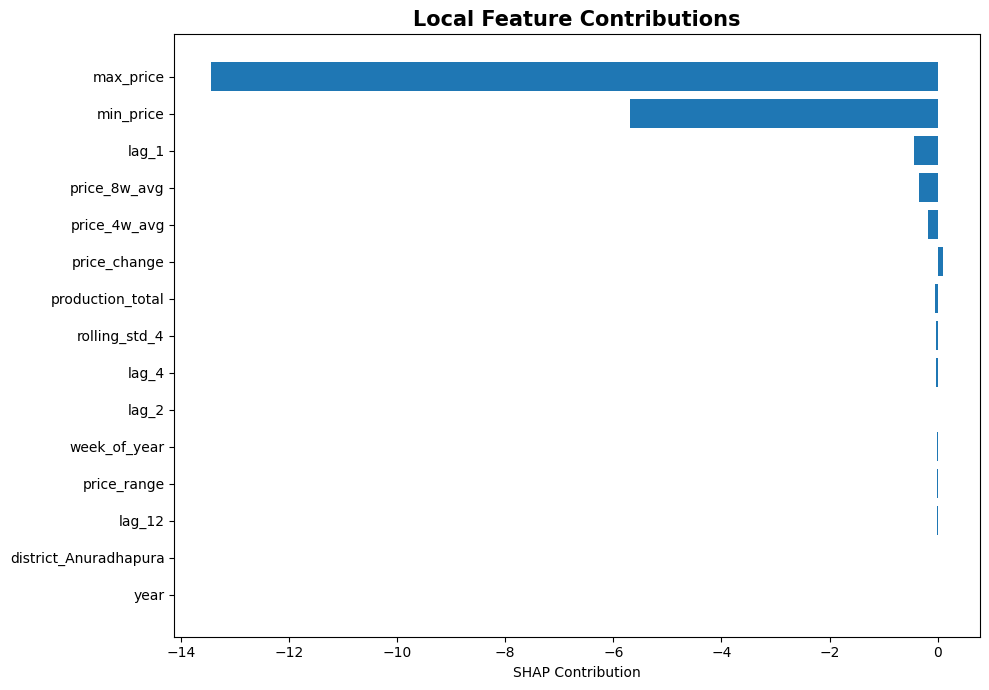

In [73]:
top_local = local_df.head(15)

plt.figure(figsize=(10,7))

bars = plt.barh(

    top_local["Feature"],

    top_local["SHAP Contribution"]

)

plt.gca().invert_yaxis()

plt.xlabel("SHAP Contribution")

plt.title(
    "Local Feature Contributions",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "local_feature_contributions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Save Results**

In [74]:
local_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "local_shap_explanation.csv"
    ),
    index=False
)

print("Local explanation saved successfully.")

Local explanation saved successfully.


**Local Prediction**

In [75]:
print("="*70)
print("LOCAL EXPLANATION SUMMARY")
print("="*70)

print(f"Actual Price      : {actual:.2f}")

print(f"Predicted Price   : {prediction:.2f}")

print(f"Prediction Error  : {prediction-actual:.2f}")

print()

print("Top Five Contributors")

display(
    local_df[
        [
            "Feature",
            "Feature Value",
            "SHAP Contribution"
        ]
    ].head()
)

LOCAL EXPLANATION SUMMARY
Actual Price      : 37.00
Predicted Price   : 37.05
Prediction Error  : 0.05

Top Five Contributors


,Feature,Feature Value,SHAP Contribution
1,max_price,38.0,-13.441557
0,min_price,36.0,-5.686107
13,lag_1,36.4,-0.434693
8,price_8w_avg,46.49375,-0.344750
7,price_4w_avg,43.0,-0.186478
